# Training Recurrent Neural Networks

## Part 1 of 5: Training an RNNs on Time Series Data

In [5]:
#Download data
!mkdir -p data
!wget -P data https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
!unzip data/jena_climate_2009_2016.csv.zip -d data
!rm data/jena_climate_2009_2016.csv.zip

--2026-03-18 15:42:05--  https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
Resolving s3.amazonaws.com (s3.amazonaws.com)... 16.15.223.56, 16.15.183.38, 54.231.194.112, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|16.15.223.56|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13565642 (13M) [application/zip]
Saving to: ‘data/jena_climate_2009_2016.csv.zip’

jena_climate_2009_2 100%[===================>]  12.94M  33.2MB/s    in 0.4s    

2026-03-18 15:42:06 (33.2 MB/s) - ‘data/jena_climate_2009_2016.csv.zip’ saved [13565642/13565642]

Archive:  data/jena_climate_2009_2016.csv.zip
  inflating: data/jena_climate_2009_2016.csv  
  inflating: data/__MACOSX/._jena_climate_2009_2016.csv  


In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

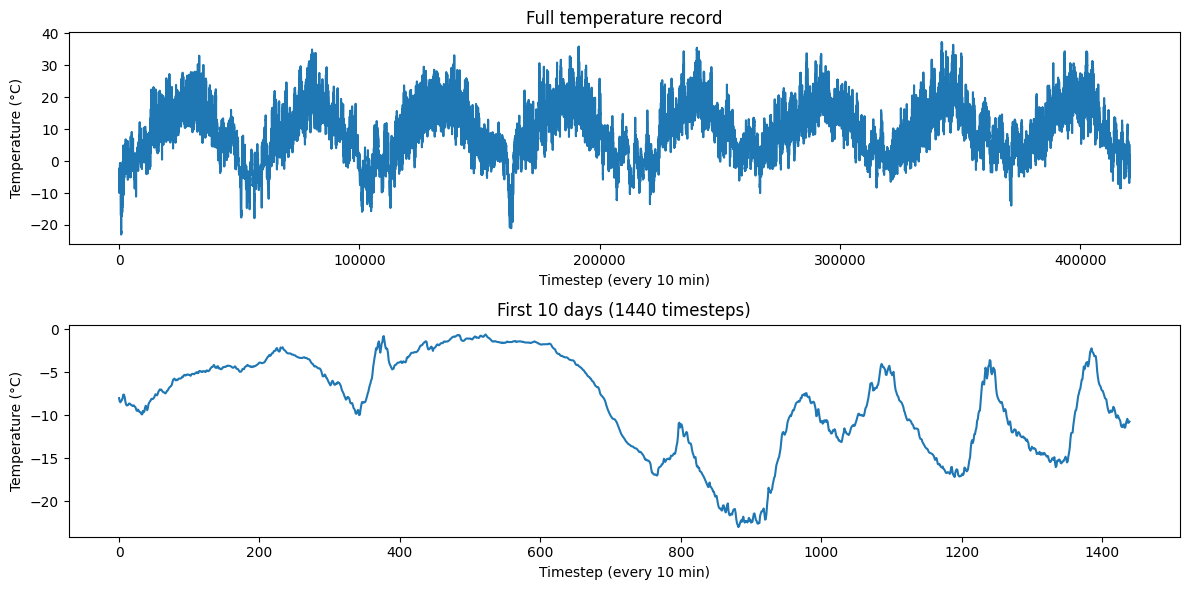

In [17]:
# --- Load data ---
fname = "data/jena_climate_2009_2016.csv"
with open(fname) as f:
    data = f.read()
lines = data.split("\n")
header = lines[0].split(",")
lines = lines[1:]

temperature = np.zeros((len(lines),))
raw_data = np.zeros((len(lines), len(header) - 1))
for i, line in enumerate(lines):
    values = [float(x) for x in line.split(",")[1:]]
    temperature[i] = values[1]
    raw_data[i, :] = values[:]

# --- Plots (before normalization, matching Keras notebook) ---
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(range(len(temperature)), temperature)
axes[0].set_title("Full temperature record")
axes[0].set_xlabel("Timestep (every 10 min)")
axes[0].set_ylabel("Temperature (°C)")

axes[1].plot(range(1440), temperature[:1440])
axes[1].set_title("First 10 days (1440 timesteps)")
axes[1].set_xlabel("Timestep (every 10 min)")
axes[1].set_ylabel("Temperature (°C)")

plt.tight_layout()
plt.show()

In [18]:
# --- Split sizes ---
num_train_samples = int(0.5 * len(raw_data))
num_val_samples   = int(0.25 * len(raw_data))
num_test_samples  = len(raw_data) - num_train_samples - num_val_samples
print("num_train_samples:", num_train_samples)
print("num_val_samples:", num_val_samples)
print("num_test_samples:", num_test_samples)

# --- Normalize ---
scaler = StandardScaler()
scaler.fit(raw_data[:num_train_samples])
raw_data = scaler.transform(raw_data)

temp_mean = scaler.mean_[1]
temp_std  = scaler.scale_[1]

num_train_samples: 210225
num_val_samples: 105112
num_test_samples: 105114


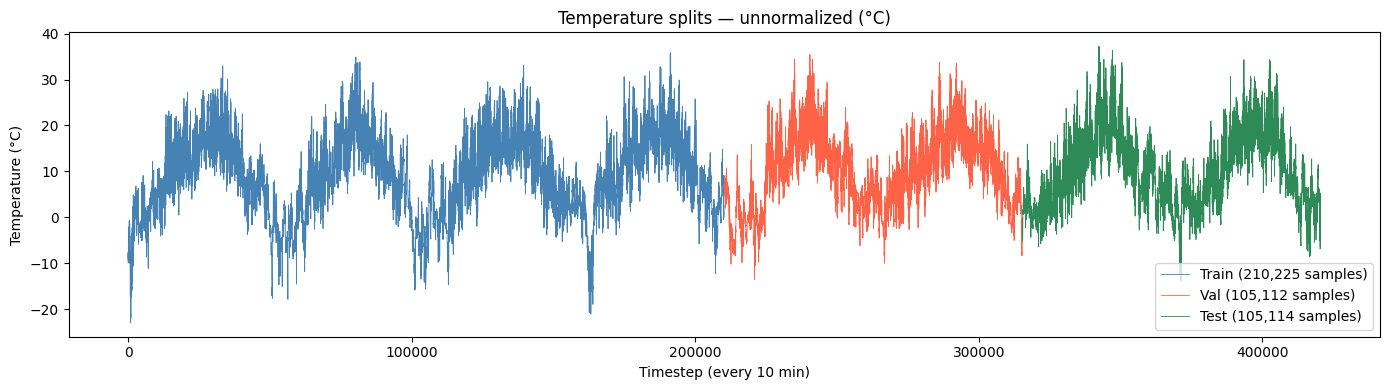

In [21]:
train_temp = temperature[:num_train_samples]
val_temp   = temperature[num_train_samples:num_train_samples + num_val_samples]
test_temp  = temperature[num_train_samples + num_val_samples:]

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(range(len(train_temp)),
        train_temp,
        label=f"Train ({len(train_temp):,} samples)", color="steelblue", linewidth=0.6)

ax.plot(range(len(train_temp), len(train_temp) + len(val_temp)),
        val_temp,
        label=f"Val ({len(val_temp):,} samples)", color="tomato", linewidth=0.6)

ax.plot(range(len(train_temp) + len(val_temp), len(temperature)),
        test_temp,
        label=f"Test ({len(test_temp):,} samples)", color="seagreen", linewidth=0.6)

ax.set_title("Temperature splits — unnormalized (°C)")
ax.set_xlabel("Timestep (every 10 min)")
ax.set_ylabel("Temperature (°C)")
ax.legend()
plt.tight_layout()
plt.show()

In [22]:
import joblib

save_dir = "data/processed"
os.makedirs(save_dir, exist_ok=True)

# --- Save arrays ---
np.save(os.path.join(save_dir, "raw_data.npy"),    raw_data)
np.save(os.path.join(save_dir, "temperature.npy"), temperature)

# --- Save split indices ---
np.save(os.path.join(save_dir, "train_idx.npy"),
        np.arange(0, num_train_samples))
np.save(os.path.join(save_dir, "val_idx.npy"),
        np.arange(num_train_samples, num_train_samples + num_val_samples))
np.save(os.path.join(save_dir, "test_idx.npy"),
        np.arange(num_train_samples + num_val_samples, len(raw_data)))

# --- Save scaler ---
joblib.dump(scaler, os.path.join(save_dir, "scaler.pkl"))

print("Saved to", save_dir)
for f in os.listdir(save_dir):
    size = os.path.getsize(os.path.join(save_dir, f)) / 1024
    print(f"  {f:30s} {size:8.1f} KB")

Saved to data/processed
  train_idx.npy                    1642.5 KB
  temperature.npy                  3284.9 KB
  raw_data.npy                    45987.0 KB
  scaler.pkl                          0.9 KB
  val_idx.npy                       821.3 KB
  test_idx.npy                      821.3 KB


In [25]:
temperature.mean()

9.44856687223957